In [1]:
#    Define input file for BOUT++

import numpy as np
import scipy
import xbout
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 200  
plt.ioff()
#%load_ext autoreload
#%autoreload 2
params = {'legend.fontsize': 8,
'legend.title_fontsize': 8,
'figure.figsize': (4.8, 4.8),
'axes.labelsize': 12,
'axes.titlesize': 15,
'xtick.labelsize':8,
'ytick.labelsize':8,
'font.family': 'serif',
'text.usetex': False}
plt.rcParams.update(params)


analyze=True

def write_BOUT_inp(grid,solution_U,source_U,solution_Apar,source_Apar,
                   xmin,xmax,nx,D_par,D_perp,nout=100,timestep=2.0):
    # Normalization, beacuse x does indeed not go from 0 to 1, this screws up
    # the calculation for the perp derivatives
    
    minvalue=(-2.0+0.5) / (nx - 2*2)
    maxvalue=(nx-3+0.5) / (nx - 2*2)
    
    
    cont = f"""
#
# Input file for 1D wave MMS test
#

nout = {nout}      # Number of output timesteps
timestep = 10.0*pi/nout  #Time between outputs
#timestep = 1e-2

grid = "{grid}"


xl= ({np.round(xmax-xmin,2)})*(x-({np.round(minvalue,8)}))/(({np.round(maxvalue,8)})-({np.round(minvalue,8)})) + ({np.round(xmin,2)})
yl=y    #/(2*pi)
zl=z


MXG=2
MYG=1

[reduced_MHD]

evolve_U = true
evolve_Apar = false

mu = 0.001
eta = 0.0
U_ExB = true
U_Delp2 = true
U_gradpar = true


[mesh:paralleltransform]
type = fci


[input]
error_on_unused_options=false


[mesh]

symmetricGlobalX = true

extrapolate_y = false


[phiSolver]

type   = petsc  # Needed if Boussinesq = false
ksptype = gmres # Linear iterative method
pctype = hypre # Preconditioner. Direct "lu" or "ilu"; iterative "jacobi", "sor"
atol=1e-12
rtol = 1e-8
factor_package = superlu_dist
inner_boundary_flags = 16
outer_boundary_flags = 16
all_terms = false
nonuniform = true   # NOTE: Necessary to avoid numerical instability

##################################################
[mesh:ddx]   # Methods used for perp (x) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT


[mesh:ddy]   # Methods used for parallel (y) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT


[mesh:ddz]   # Methods used for perp (z) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT


[solver]

mms = true
mms_initialise = true
atol = 1e-12 # absolute tolerance
rtol = 1e-8  # relative tolerance
mxstep = 1000000


[U]

bndry_xin = dirichlet(U:solution)
bndry_xout = dirichlet(U:solution)
solution = {solution_U}
source = {source_U}


[Apar]

bndry_xin = dirichlet(Apar:solution)
bndry_xout = dirichlet(Apar:solution)
solution = {solution_Apar}
source = {source_Apar}




    """
    return cont

def write_slurmfile(id,nodes,ntasks_per_node, mem,time_h,time_min,
                   executable,directory):
    content=f"""#!/bin/bash -l                                                                                                                                        
# Standard output and error:                                                                                                                          
#SBATCH -o ./job_hybrid.out.%j                                                                                                                        
#SBATCH -e ./job_hybrid.err.%j                                                                                                                        
# Initial working directory:                                                                                                                          
#SBATCH -D ./                                                                                                                                         
# Job Name:                                                                                                                                           
#SBATCH -J MMS_axial_circle_{int(id)}                                                                                                                         
#                                                                                                                                                     
# Number of nodes and MPI tasks per node:                                                                                                             
#SBATCH --nodes={nodes}                                                                                                                                    
#SBATCH --ntasks-per-node={int(ntasks_per_node)}                                                                                                                          
#SBATCH --mem={int(mem)}GB                                                                                                                                    

# for OpenMP:                                                                                                                                         
#SBATCH --cpus-per-task=1                                                                                                                             
#SBATCH --mail-type=all                                                                                                                               
#SBATCH --mail-user=toto@ipp.mpg.de                                                                                                                   
#                                                                                                                                                     
# Wall clock limit (max. is 24 hours):                                                                                                                
#SBATCH --time={int(time_h)}:{int(time_min)}:00                                                                                                                               
set -x
# Load compiler and MPI modules (must be the same as used for compiling the code)                                                                     
module purge
module load gcc/13 openmpi/4.1 hdf5-serial/1.14.1 netcdf-serial/4.9.2 fftw-mpi/3.3.10 anaconda/3/2021.11 mkl/2024.0

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# For pinning threads correctly:                                                                                                                      
export OMP_PLACES=cores

# Run the program                                                                                                                                     

srun {executable} -d {directory} $@
    
    """
    return content


def gridfile_string(nx,ny,nz,rho_1,xmin,xmax,Ly,B0,q0,q1,directory):
    content = f"{directory}/cor_mms_Axial_Circle_{nx}_{ny}_{nz}_{rho_1}_{xmin}_{xmax}_{np.round(Ly,3)}_{B0}_{q0}_{q1}.fci.grid.nc"
    return content

def read_solution_source(var):
    with open(f"solution_{var}.txt", "r") as file:
        solution = file.read()
        
    with open(f"source_{var}.txt", "r") as file:
        source = file.read()
    
    return solution,source

In [2]:
grids=[]
grids.append([20,16,64])
grids.append([36,32,128])
grids.append([52,48,192])
grids.append([68,64,256])
cores=[16,32,32,128]

rundir="/u/toto/soft/hermes-2-new/hermes-2/MMS/reduced_MHD"

for i in range(len(grids)):
    id = i
    grindfilename=gridfile_string(nx=grids[i][0],ny=grids[i][1],nz=grids[i][2],rho_1=0.0,
                                  xmin=0.4,xmax=0.6,Ly=2*np.pi,B0=1.0,q0=8.0,q1=-0.2,
                                     directory=rundir)
    solution_U,source_U = read_solution_source("U")
    solution_Apar,source_Apar = read_solution_source("Apar")
    BOUTinp=write_BOUT_inp(grid=grindfilename,solution_U=solution_U,source_U=source_U,
                           solution_Apar=solution_Apar,source_Apar=source_Apar,
                           xmin=0.4,xmax=0.6,nx=grids[i][0],
                           nout=50,D_par = 1.0,D_perp = 1e-5)
    exec_dir=rundir+"/build/reduced_MHD"
    directory=f"{rundir}/data_{id}"
    slurmbatch=write_slurmfile(id,1,cores[i],64,8,0,exec_dir,directory)

    with open(f"data_{int(id)}/BOUT.inp", "w") as file:
        file.write(BOUTinp)

    with open(f"data_{int(id)}/slurmbatch", "w") as file:
        file.write(slurmbatch)


In [5]:
if (analyze)==True:
    L2={}
    Linf={}
    L2_phi={}
    yspacings={}
    var="U"
    xfit=[]
    yfit=[]
    yfitphi=[]
    #for i in range(2):
    for i in [0,1]: 
        id = i
        try:
            grindfilename=gridfile_string(nx=grids[i][0],ny=grids[i][1],nz=grids[i][2],rho_1=0.0,xmin=0.4,xmax=0.6,Ly=2*np.pi,B0=1.0,q0=8.0,q1=-0.2,
                                         directory=rundir)
            results=xbout.open_boutdataset(datapath=f"{rundir}/data_{id}/BOUT.dmp.nc",
                                  gridfilepath=grindfilename,geometry="fci")
            yspacings[str(id)]=results.y.size
            xfit.append(results.y.size)
            nt=results["t"].size
            
            L2_phi[str(id)]=np.sqrt((((results["phi"]-results["phi_solution"]).isel(x=slice(2,-2))**2).mean()))
            yfitphi.append(L2_phi[str(id)])
            L2[str(id)]=np.sqrt(((results["E_"+var])**2).isel(x=slice(2,-2),t=slice(None,None),z=slice(None,None)).mean()).values
            yfit.append(L2[str(id)])
            Linf[str(id)]=results["E_"+var].isel(x=slice(2,-2),t=slice(None,None),z=slice(None,None)).max()
        except:
            print(f"Failed at {i}")

    initial_guesses = [5, -2.0]
    xfit=1.0/np.array(xfit)
    yfit=np.array(yfit)
    yfitphi=np.array(yfitphi)

    def fitfunction(x,a,b):
        return a*x**b


    popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)
    popt_phi, pcov_phi = curve_fit(fitfunction, xfit,yfitphi, maxfev=1000,p0=initial_guesses)



Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (t: 51, x: 20, y: 16, z: 64)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
  * t                   (t) float64 0.0 0.6283 1.257 1.885 ... 30.16 30.79 31.42
    R                   (x, y, z) float64 0.3995 0.3957 0.388 ... 0.5935 0.5993
    Z                   (x, y, z) float64 0.01963 0.05869 ... -0.08804 -0.02944
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
  * y                   (y) float64 0.1963 0.589 0.9817 ... 5.301 5.694 6.087
  * z                   (z) float64 0.0 0.09817 0.1963 ... 5.989 6.087 6.185
Data variables: (12/42)
    Apar                (t, x, y, z) float64 dask.array<chunks

/tmp/ipykernel_3773477/4288099254.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)
/tmp/ipykernel_3773477/4288099254.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_phi, pcov_phi = curve_fit(fitfunction, xfit,yfitphi, maxfev=1000,p0=initial_guesses)


<IPython.core.display.Javascript object>


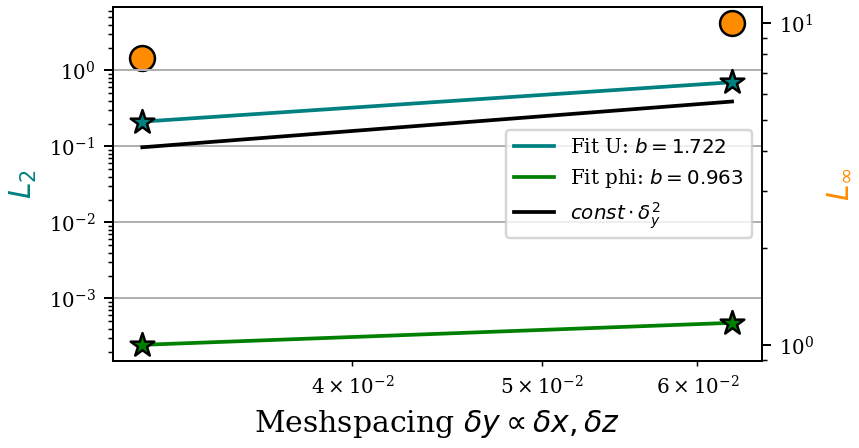

In [6]:
if (analyze)==True:
    %matplotlib notebook
    plt.close()
    fig,(ax) = plt.subplots(1,1,figsize=(4.8,2.5),layout="constrained")
    for key in L2:
        ax.scatter(1.0/yspacings[key],L2[key],color="teal",marker="*",s=100,edgecolor="black",zorder=10)
    ax.plot(xfit,fitfunction(xfit, *popt_N),label=f'Fit {var}: $b={popt_N[1]:.3f}$',color="teal")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    
    for key in L2_phi:
        ax.scatter(1.0/yspacings[key],L2_phi[key],color="green",marker="*",s=100,edgecolor="black",zorder=10)
    ax.plot(xfit,fitfunction(xfit, *popt_phi),label=f'Fit phi: $b={popt_phi[1]:.3f}$',color="green")
    
    ax.set_ylabel(r"$L_2$",color="teal")
    ax.set_xlabel(r"Meshspacing $\delta y \propto \delta x,\delta z$")

    ax_twin=ax.twinx()
    for key in L2:
        ax.scatter(1.0/yspacings[key],Linf[key],color="darkorange",s=100,edgecolor="black")
    ax_twin.set_yscale("log")
    ax_twin.set_ylabel(r"$L_\infty$",color="darkorange")
    ax.plot(xfit,100*xfit**2,color="black",label=r"$const \cdot \delta_y^2$")

    ax.legend()
    plt.show()

In [10]:
#LOAD MANUAL STUFF
iddd=0
grindfilename=gridfile_string(nx=grids[iddd][0],ny=grids[iddd][1],nz=grids[iddd][2],rho_1=0.0,xmin=0.4,xmax=0.6,Ly=2*np.pi,B0=1.0,q0=8.0,q1=-0.2,
                                 directory=rundir)
df=xbout.open_boutdataset(datapath=f"{rundir}/data_{iddd}/BOUT.dmp.nc",
                          gridfilepath=grindfilename,geometry="fci").isel(x=slice(2,-2))

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (t: 51, x: 20, y: 16, z: 64)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(20, 16, 64), meta=np.ndarray>
  * t                   (t) float64 0.0 0.6283 1.257 1.885 ... 30.16 30.79 31.42
    R                   (x, y, z) float64 0.3995 0.3957 0.388 ... 0.5935 0.5993
    Z                   (x, y, z) float64 0.01963 0.05869 ... -0.08804 -0.02944
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
  * y                   (y) float64 0.1963 0.589 0.9817 ... 5.301 5.694 6.087
  * z                   (z) float64 0.0 0.09817 0.1963 ... 5.989 6.087 6.185
Data variables: (12/42)
    Apar                (t, x, y, z) float64 dask.array<chunks

<IPython.core.display.Javascript object>


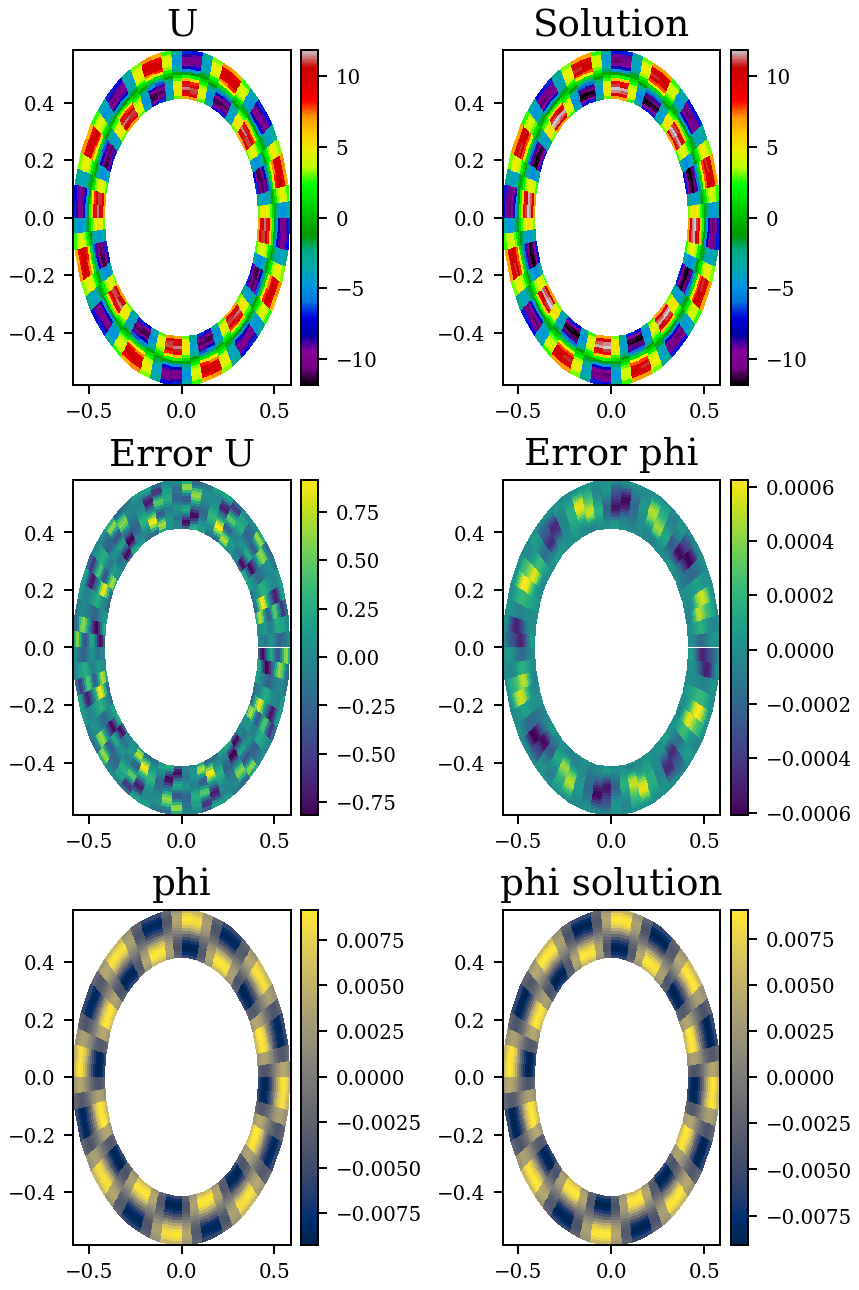

/tmp/ipykernel_3772398/2229343061.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
/tmp/ipykernel_3772398/2229343061.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
/tmp/ipykernel_3772398/2229343061.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically incre

In [11]:
%matplotlib notebook
plt.close()
thist=-1
thisy=5

Field="U"
df_solution=df[Field]-df["E_"+Field]
vmin=np.min(df_solution.isel(y=thisy,t=thist).values)
vmax=np.max(df_solution.isel(y=thisy,t=thist).values)
fig,((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize=(4.8,3*2.4),layout="constrained")
a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
c=ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["E_"+Field].isel(y=thisy,t=thist))
e=ax5.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=thist),cmap="cividis")
f=ax6.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=thist),cmap="cividis")
d=ax4.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(df["phi"]-df["phi_solution"]).isel(y=thisy,t=thist),cmap="viridis")
ax1.set_title(Field)
ax2.set_title("Solution")
ax3.set_title(f"Error {Field}")
ax4.set_title(f"Error phi")

ax5.set_title("phi")
ax6.set_title("phi solution")
plt.colorbar(a)
plt.colorbar(b)
plt.colorbar(c)
plt.colorbar(e)
plt.colorbar(f)
plt.colorbar(d)
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(4.8,2.0),layout="constrained")
line, = ax1.plot([], [], lw=2)  # Create an empty line object to update during animation

thisy=5
# Define the initialization function
def init():
    line.set_data([], [])
    return line,

Field = "U"
# Define the update function for each frame
def update(frame):
    ax1.cla()
    ax2.cla()
    ax3.cla()
    vmin=np.min(df_solution.isel(y=thisy).values)
    vmax=np.max(df_solution.isel(y=thisy).values)
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
    ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
    ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["E_"+Field].isel(y=thisy,t=frame))
    
    return line,

# Set up and run the animation
frames = (df["t"].size)  # Number of time steps
anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True,interval=100)
#anim.save("/u/toto/MMS_Loki/animation.gif", writer="pillow", fps=5)
# Display the animation in the notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>


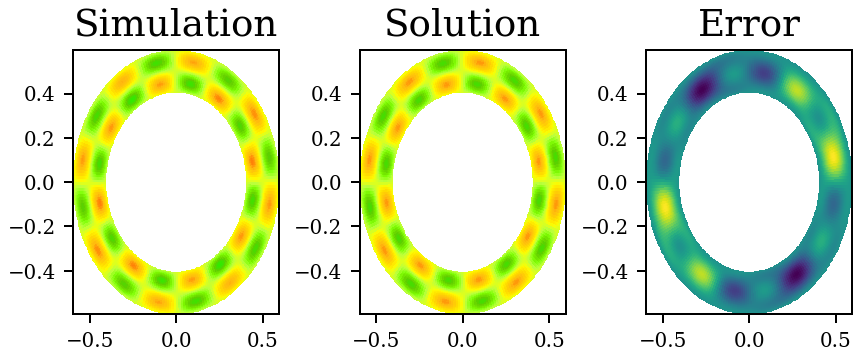

/tmp/ipykernel_3130066/205495482.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or

/tmp/ipykernel_3130066/205495482.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or

/tmp/ipykernel_3130066/205495482.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or

/tmp/ipykernel_3130066/205495482.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or

/tmp/ipykernel_3130066/205495482.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
/tmp/ipykernel_3130066/205495482.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or

In [7]:
from matplotlib.animation import FuncAnimation
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(4.8,2.0),layout="constrained")
line, = ax1.plot([], [], lw=2)  # Create an empty line object to update during animation

thisy=15
# Define the initialization function
def init():
    line.set_data([], [])
    return line,

Field = "U"
# Define the update function for each frame
def update(frame):
    ax1.cla()
    ax2.cla()
    ax3.cla()
    vmin=np.min(df["phi_solution"].isel(y=thisy).values)
    vmax=np.max(df["phi_solution"].isel(y=thisy).values)
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
    ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["phi_solution"].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="gist_ncar")
    ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),(df["phi"]-df["phi_solution"]).isel(y=thisy,t=frame))
    
    return line,

# Set up and run the animation
frames = (df["t"].size)  # Number of time steps
anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True,interval=100)
#anim.save("/u/toto/MMS_Loki/animation.gif", writer="pillow", fps=5)
# Display the animation in the notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

In [8]:
%matplotlib notebook
plt.close()
thist=-1
thisy=2
thisz=8
fig,ax=plt.subplots()
df["phi"].isel(y=thisy,t=thist,z=thisz).plot(ax=ax,label="phi")
df["phi_solution"].isel(y=thisy,t=thist,z=thisz).plot(ax=ax,label="phi solution")
df["phi_boundary"].isel(y=thisy,t=thist,z=thisz).plot(ax=ax,label="phi boundary",linestyle="dotted")
plt.legend()
plt.show()

AttributeError: 'NoneType' object has no attribute 'remove_callback'

In [8]:
%matplotlib notebook
plt.close()
thist=-1
thisy=5
thisz=8
fig,ax=plt.subplots()
df["U"].isel(y=thisy,t=thist,z=thisz).plot(ax=ax,label="U")
df_solution.isel(y=thisy,t=thist,z=thisz).plot(ax=ax,label="U solution")

plt.legend()
plt.show()

AttributeError: 'NoneType' object has no attribute 'remove_callback'

<IPython.core.display.Javascript object>


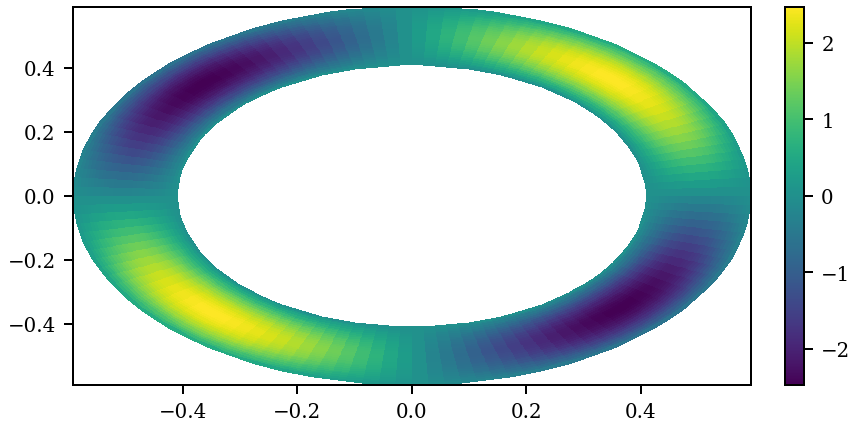

/tmp/ipykernel_727013/2438703469.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a=ax.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["Jpar"].isel(y=thisy,t=thist))


In [11]:
%matplotlib notebook
plt.close()
thist=-1
thisy=2
fig,ax = plt.subplots(figsize=(4.8,1*2.4),layout="constrained")
a=ax.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["Jpar"].isel(y=thisy,t=thist))
plt.colorbar(a)
plt.show()

<IPython.core.display.Javascript object>


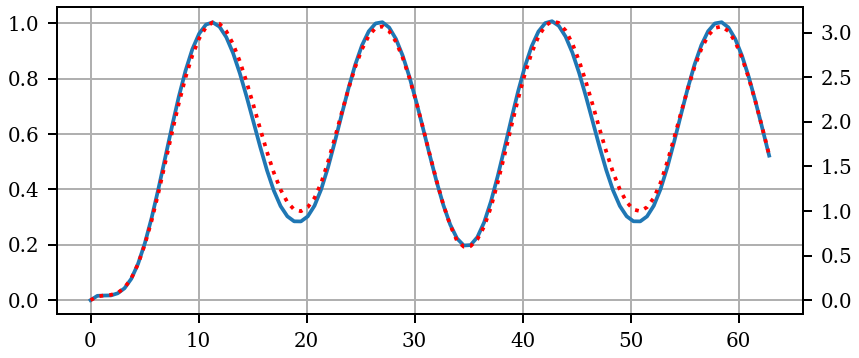

In [13]:
%matplotlib notebook
plt.close()
thisy=5
fig,(ax) = plt.subplots(1,1,figsize=(4.8,2),layout="constrained")
ax.plot(df.t,np.sqrt(((df["E_U"])**2).mean(dim=("x","z","y"))),label="n")
ax_twin = ax.twinx()
ax_twin.plot(df.t,df["E_U"].max(dim=("x","y","z")),color="red",linestyle="dotted")
ax.grid()
plt.show()

In [8]:
%matplotlib notebook
plt.close()
thisy=12
thist=-1
thisx=10
fig,(ax) = plt.subplots(1,1,figsize=(4.8,2),layout="constrained")
ax.plot(df["U"].isel(t=thist,x=thisx,y=thisy),label="simulation")
ax.plot(df_solution.isel(t=thist,x=thisx,y=thisy),label="solution")
ax.grid()
plt.legend()

AttributeError: 'NoneType' object has no attribute 'remove_callback'

<IPython.core.display.Javascript object>


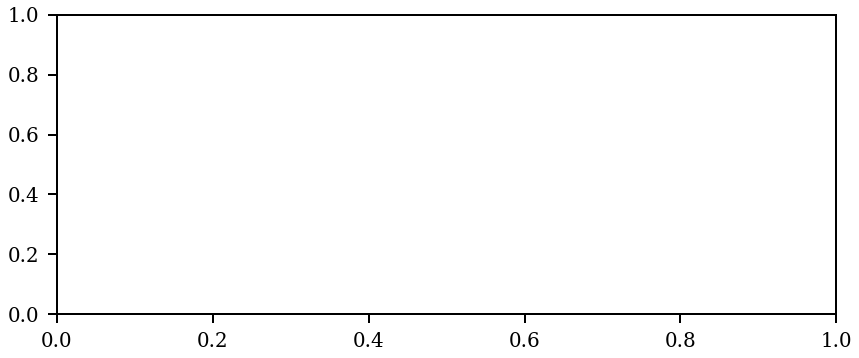

IndexError: Index 12 is out of bounds for axis 2 with size 8

In [12]:
%matplotlib notebook
plt.close()
thisy=12
thist=-1
thisz=20
fig,(ax) = plt.subplots(1,1,figsize=(4.8,2),layout="constrained")
ax.plot(df["U"].isel(t=thist,z=thisz,y=thisy),label="simulation")
ax.plot(df_solution.isel(t=thist,z=thisz,y=thisy),label="solution")
ax.grid()
plt.legend()

In [7]:
df.xl.isel(z=0,y=0).values

array([0.4       , 0.40571429, 0.41142857, 0.41714286, 0.42285714,
       0.42857143, 0.43428571, 0.44      , 0.44571429, 0.45142857,
       0.45714286, 0.46285714, 0.46857143, 0.47428571, 0.48      ,
       0.48571429, 0.49142857, 0.49714286, 0.50285714, 0.50857143,
       0.51428571, 0.52      , 0.52571429, 0.53142857, 0.53714286,
       0.54285714, 0.54857143, 0.55428571, 0.56      , 0.56571429,
       0.57142857, 0.57714286, 0.58285714, 0.58857143, 0.59428571,
       0.6       ])

In [9]:
df_solution

<xarray.DataArray (t: 10, x: 36, y: 32, z: 128)>
dask.array<sub, shape=(10, 36, 32, 128), dtype=float64, chunksize=(10, 18, 8, 128), chunktype=numpy.ndarray>
Coordinates:
    dx       (x, y, z) float64 dask.array<chunksize=(18, 8, 128), meta=np.ndarray>
    dy       (x, y, z) float64 dask.array<chunksize=(18, 8, 128), meta=np.ndarray>
    dz       (x, y, z) float64 dask.array<chunksize=(18, 8, 128), meta=np.ndarray>
  * t        (t) float64 0.0 0.6283 1.257 1.885 2.513 ... 3.77 4.398 5.027 5.655
    R        (x, y, z) float64 0.3999 0.3989 0.397 ... 0.5955 0.5984 0.5998
    Z        (x, y, z) float64 0.009816 0.02943 0.04896 ... -0.04414 -0.01472
  * x        (x) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * y        (y) float64 0.09817 0.2945 0.4909 0.6872 ... 5.792 5.989 6.185
  * z        (z) float64 0.0 0.04909 0.09817 0.1473 ... 6.087 6.136 6.185 6.234
Attributes:
    current_time_index:  10
    cell_location:       CELL_CENTRE
    description:         
    direction_y:         Standard
    direction_z:         Standard
    source:              Solver
    time_dimension:      t
    metadata:            {'BOUT_VERSION': 5.2, 'MXG': 2, 'MXSUB': 16, 'MYG': ...
    options:             None
    regions:             {'all': <xbout.region.Region>\n\tname\tall\n\txinner...
    geometry:            fci

In [5]:
L2

{'0': array(0.14791127),
 '1': array(0.04139737),
 '2': array(0.),
 '3': array(0.01077745)}